# Gender Bias in Wikipedia-Biografien in der Wissenschaft



In [2]:
import pandas as pd
from nltk.corpus import stopwords

In [3]:
import sys
sys.path.append('../src')
from src.functions import plot_gender, preprocessing, rang_corr, pmi, lexikon_analyse, plot_rank_scatter, plot_lexikon, plot_pmi

# 1 Motivation

Wikipedia ist das größte frei zugängliche Wissensarchiv. Sie wird von vielen Personen als neutrale Quelle wahrgenommen [@elmimouni_why_2022]. Gleichzeitig ist sie eine wichtige Grundlage, um beispielsweise Sprachmodelle zu trainieren. Verzerrungen in den Artikeln können sich so auf nachgelagerte Systeme übertragen [@criado-perez_unsichtbare_2020]. Um einen möglichen Bias nicht auf andere Systeme zu übertragen ist es zwingend notwendig diesen zu testen und ggf. gegenzusteuern. Wir untersuchen, ob ein Gender Bias den Wikipedia-Biografien von deutschen Wissenschaftlerinnen und Wissenschaftlern zu finden ist. Wir haben uns dabei auf eine sprachliche Auswertung fokussiert, da Wikipedia Artikel mit den Biografien der Wissenschaftler bereitstellt.

@hyde_gender_2005 beschreibt, dass sich Männer und Frauen in den meisten psychologischen Merkmalen kaum unterscheiden. Dennoch zeigen sich in den Biografien deutliche Unterschiede, spricht das eher für eine sozial konstruierte Verzerrung in der Darstellung als für biologische Unterschiede. Viele Datensätze sind implizit männlich geprägt, weil Männer lange als die Norm galten. Dasselbe gilt für Wikipedia: Hier waren sowohl die Biografien als auch die Autoren sehr lange männlich geprägt.


## 1.1 Gender Bias
# Drei Absätze hier zusammefügen
Gender Bias kann auf mehreren Ebenen entstehen. Strukturell sind Frauen in der Wissenschaft historisch unterrepräsentiert, was auch in Biografien auffält [@konieczny_gender_2018, @wagner_its_2015]. Wir betrachtet jedoch nicht ob oder wie viele Artikel existieren, sondern wie die Wissenschaftler:innen beschrieben werden in ihren Biografien. @graells-garrido_first_2015 zeigen, dass Frauenbiografien häufiger eheliche und familiären Inhalte enthalten, während männliche Biografien stärker mit kongitiven Prozessen assoziiert werden. @sun_men_2021 weisen nach, dass private Ereignisse wie eine Heirat bei Frauen sogar im Karriere-Abschnitt auftauchen, bei Männern hingegen im Abschnitt zum Privatleben. @wagner_its_2015 bestätigen über sechs Sprachen hinweg, dass Begriffe aus den Bereichen Familie und Beziehung deutlich häufiger Frauenbiografien zugeordnet werden, und @brun_wikigender_2022 finden, dass Frauen eher mit Familie, Männer eher mit Beruf und Sport assoziiert werden.

@konienczny_gender_2ß18 finden auf der Ebene der Abdeckung (Coverage) über alle Wikipedia-Sprachversionen hinweg einen globalen Frauenanteil von nur rund 15-16% unter den Biografien, der seit dem 19. Jahrhundert aber stetig steigt. @wagner_its_2015 zeigen sogar, dass Frauen im Vergleich zu externen Referenzlisten erwähnenswerter Personen auf Wikipedia eher leicht über- als unterrepräsentiert sind. Auf sprachlicher und inhaltlicher Ebene fallen die Befunde dagegen deutlich konsistenter aus. Graells-Garrido et al. @graells-garrido_first_2015 zeigen, dass Frauenbiografien stärker mit Ehe und Sexualität, Männerbiografien stärker mit kognitiven Prozessen assoziiert sind und Männer im Verlinkungsnetzwerk zentraler positioniert sind. @wagner_its_2015 bestätigen über sechs Sprachversionen, darunter Deutsch, dass Begriffe aus den Kategorien Familie, Beziehung und Geschlecht deutlich häufiger in Frauenbiografien vorkommen. @sun_men_2021 erweitern diese Befunde um eine andere Perspektive: Private Ereignisse wie eine Heirat erscheinen bei Frauen sogar im Karriere-Abschnitt, bei Männern hingegen im Privatleben - ein Beleg dafür, dass private und berufliche Befunde bei Frauen stärker vermischt werden. @brun_wikigender_2022 bestätigen dies mit einem Machine-Learning Ansatz: Frauen werden eher mit Familie, Männer eher mit Beruf und Sport asoziiert, und die für Frauen typischen Adjektive fallen zudem subjektiver aus.

Linguistischer Bias im bezeichnet dabei eine Asymmetrie in der Wortwahl, die soziale Kategorisierungen widerspiegelt [@brun_wikigender_2022]. Unsere Arbeit fokussiert sich auf genau diese lexikalische bzw. inhaltliche Dimension: Wir untersuchen nicht, wie viele Biografien existieren, sondern mit welchen Wörtern und Themen Wissenschaftler:innen beschrieben werden. Methodisch orientieren wir uns für den ersten Teil am Vorgehen von @graells-garrido_first_2015, um explorativ zu untersuchen welche Verben überproportional mit einem Geschlecht assoziiert werden. Für die darauffolgende, theoriegeleitete Analyse stützen wir uns auf @omrani_sabbaghi_measuring_2022 und weitere Wörter, die selbst hinzugefügt haben.


Diskriminierung kann sich auf verschiedenen Ebenen abspielen, das beschreibt die Soziologin @collins_black_1990 mit dem Konzept der "Matrix of Domination": Unterdrückungs- und Priviligierungsverhältnisse sind nicht additiv, sondern eher verschränkt. Wer in einer Hinsicht privilegiert ist, kann genauso in einer anderen benachteiligt sein. Diese Achsen lassen sich. nicht einfach zusammenfügen. Collins wendet sich damit explizit gegen Ansätze, die Kategorien wie race, class oder gender als getrennte, sich gegenseitig ausschließende Unterdrückungsformen behandeln. Treffend bringt sie das auf den Punkt, wenn sie schreibt, eine Matrix of Domination "contains few pure vicntims or opressors". Ein und dieselbe Person kann je nach Kontext gleichzeitig privilegier und benachteiligt sein.
# Satz ändern:

Datensätze und Analysemethoden selbst Teil solcher Machtstrukturen sind. @dignazio_data_2020 greifen Collins' Konzept explizit auf und fordern, binäre Geschlechterkategorisierungen in Daten kritisch zu hinterfragen, da sie reale soziale Komplexität verdecken. Unsere Arbeit betrachtet nur das Geschlecht und blendet damit andere mögliche Achsen wie Herkunft, Fachrichtung oder Status aus. Wir untersuchen wie sich die Kategorie Geschlecht in der sprachlichen Darstellung von Wissenschaftler:innen auf Wikipedia zeigt.

Als mögliche Erklärung wird in der Literatur häufig die demografische Schieflage der Wikipedia-Autor:innenschaft angeführt, von der laut @graells-garrido_first_2015 nur rund 16% Frauen sind.

Trotz dieser umfangreichen Forschung fällt auf, dass die meisten Studien entweder die englischsprachige Wikipedia oder allgemeine Personengruppen wie Prominente, Politiker:innen oder Sportler:innen in den Blick nehmen. Spezifisch auf Wissenschaftler:innen sind rar. Genau hier setzt unsere Arbeit an, indem sie Worthäufigkeits-, PMI- und Lexikon-basierte Methoden auf eine Stichprobe deutscher Wikipedia-Biografien von Wissenschaftler:innen anwendet.

Daraus ergeben sich für uns folgende Forschungsfragen:
1. Bestehen sprachliche Unterschiede zwischen den Biografien von Wissenschaftler:innen?
2. Werden in Biografien bei Wissenschaftlerinnen eher private Themen (Familie, Ehe, Kinder) angesprochen, während bei Wissenschaftlern eher berufliche Themen (Karriereerfolge) im Vordergrund stehen?

# 2 Daten und Methode


 Für unsere Analyse werten wir 610 Wikipedia-Artikel aus. Wir betrachen die Biographien von deutschen Wissenschaftler:innen, die zwischen 1950 und 2000 geboren sind. Denn der Jüngste Wissenschaftler, über den es eine Wikipedia-Biographie gibt, ist im Jahr 2000 geboren. So haben wir die letzten 50 Jahre mit einbezogen. Wir wollen eine aktuellere Analyse machen, denn es ist anzunehmen, dass vor allem in den letzten Jahren eine stärkere Sensibilisierung für Gender Bias stattgefunden hat, die sich in den Biographien widerspiegeln könnte.

Zunächst haben wir mittels SPARKL-Abfrage eine Liste ausgeben lassen aller deutschen Wikipedia-Artikel Titel von Wissenschaftler:innen. Mit Hilfe der Wikipedia-API konnten wir dann die tatsächlichen Texte herunterladen und in einem DataFrame speichern. Dabei wurden die Artikel nach Geschlecht gefiltert, um zwei Gruppen zu bilden: männliche und weibliche Wissenschaftler:innen.


In [4]:
"""df_wiki = pd.read_csv("../data/wiki_results.csv") # Datensatz mit dem Namen der Person, der URL und dem Geschlecht

df_wiki["title"] = df_wiki["article"].str.split("/").str[-1]
df_wiki["title"] = df_wiki["title"].str.replace("_", " ")

# Wikipedia Artikel herunterladen (kann etwas dauern). Es kann gleich mit der wikipedia_text.csv gearbeitet werden, in der sind die Texte enthalten.
wiki = wikipediaapi.Wikipedia(
    language='de',
    user_agent='research-project'
)

data = []

for title in df_wiki["title"]:
    page = wiki.page(title)

    if page.exists():
        data.append({
            "title": title,
            "text": page.text
        })

df = pd.DataFrame(data)

print(df["text"][0][:1000])"""

'df_wiki = pd.read_csv("../data/wiki_results.csv") # Datensatz mit dem Namen der Person, der URL und dem Geschlecht\n\ndf_wiki["title"] = df_wiki["article"].str.split("/").str[-1]\ndf_wiki["title"] = df_wiki["title"].str.replace("_", " ")\n\n# Wikipedia Artikel herunterladen (kann etwas dauern). Es kann gleich mit der wikipedia_text.csv gearbeitet werden, in der sind die Texte enthalten.\nwiki = wikipediaapi.Wikipedia(\n    language=\'de\',\n    user_agent=\'research-project\'\n)\n\ndata = []\n\nfor title in df_wiki["title"]:\n    page = wiki.page(title)\n\n    if page.exists():\n        data.append({\n            "title": title,\n            "text": page.text\n        })\n\ndf = pd.DataFrame(data)\n\nprint(df["text"][0][:1000])'

### Geschlechterverteilung in den Wikipedia-Biografien
Für unser Analyse betrachten wir nur Männliche und Weibliche Personen. Alle weiteren Personen wurden entfernt, da von ihnen zu wenige enthalten sind.

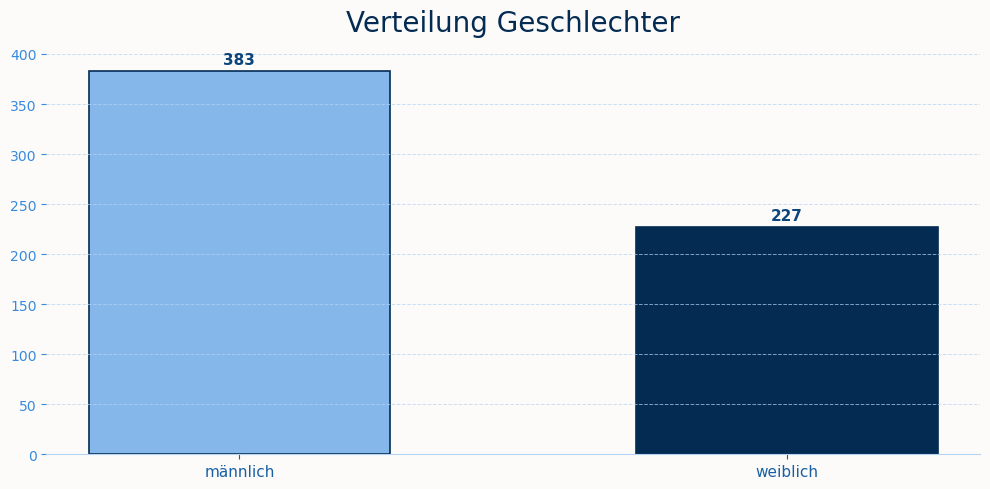

In [5]:
df = pd.read_csv("../data/wikipedia_text.csv", sep = ",") #Datensatz einlesen
plot_gender(data = df)

## 2.2 Preprocessing: Stopwörter, Tokenisierung und Corpora
Die Stoppwörter werden nach der Standardliste von NLTK für Deutsch und Englisch erweitert um häufige, aber wenig informative Wörter aus Wikipedia-Texten (z.B. "abgerufen", "online", "doi").
 Die Tokenisierung erfolgt durch eine einfache Regex, die nur alphabetische Zeichen und deutsche Umlaute berücksichtigt.
 Gesamtheit aller Verben, die in den Texten der männlichen bzw. weiblichen Artikel vorkommen. Diese werden durch die Funktion `collect_corpora` erstellt, die die Texte der Artikel nach Geschlecht filtert und dann tokenisiert. Das Ergebnis ist ein Dictionary mit zwei Listen von Tokens: eine für "männlich" und eine für "weiblich". Diese Corpora bilden die Grundlage für die anschließende Häufigkeitsanalyse und PMI-Berechnung.

In [6]:
STOPWORDS = set(stopwords.words("german")) | set(stopwords.words("english"))
corpus = preprocessing(data = df, STOPWORDS = STOPWORDS, nur_verben=True)

# 3 Ergebnisse
## 3.1 Häufigkeitsanalyse und Rang-Korrelation
Die Funktion `word_frequencies` berechnet die relative Häufigkeit jedes Tokens in einem gegebenen Corpus, indem sie die Anzahl der Vorkommen eines Tokens durch die Gesamtzahl der Tokens teilt. Das Ergebnis ist ein Dictionary, das jedem Token seine relative Häufigkeit zuordnet.
Die Funktion `rank_correlation` berechnet die Spearman-Rangkorrelation zwischen den Häufigkeiten der gemeinsamen Tokens in den männlichen und weiblichen Corpora. Sie identifiziert die gemeinsamen Tokens, extrahiert ihre Häufigkeiten aus beiden Corpora und berechnet dann die Spearman-Korrelation, um zu bewerten, wie ähnlich die Rangordnungen der Token-Häufigkeiten zwischen den beiden Gruppen sind. Das Ergebnis umfasst den Korrelationskoeffizienten (ρ), den p-Wert und die Anzahl der gemeinsamen Tokens, die in die Berechnung einbezogen wurden.

### Interpretation Rang Korrelation
Ein hoher Spearman-Korrelationskoeffizient (ρ) nahe 1 würde darauf hindeuten, dass die Rangordnungen der Token-Häufigkeiten in den männlichen und weiblichen Corpora sehr ähnlich sind, was auf eine geringe sprachliche Verzerrung hinweisen könnte. Ein niedrigerer ρ-Wert würde hingegen auf größere Unterschiede in der Wortwahl zwischen den beiden Gruppen hindeuten, was auf ein sehr unterschiedliches Vokabular hindeuten.

Die Rangkorrelation von ρ = 0.52 in unserer Analyse steht für eine moderate positive Korrelation zwischen den Häufigkeiten der gemeinsamen Tokens in den männlichen und weiblichen Biografien. Das bedeutet, dass es eine gewisse Ähnlichkeit in der Wortwahl gibt, aber auch signifikante Unterschiede. Einige Wörter könnten in beiden Gruppen häufig vorkommen, während andere möglicherweise in einer Gruppe deutlich häufiger sind als in der anderen. Der p-Wert von 2.3e-16 zeigt, dass diese Korrelation statistisch hoch signifikant ist, was darauf hindeutet, dass die beobachtete Ähnlichkeit nicht zufällig ist. Insgesamt deutet dies auf eine gewisse Überschneidung im Vokabular hin, aber auch auf spezifische Unterschiede in der Wortwahl zwischen männlichen und weiblichen Biografien.

Vokabular ist mäßig ähnlich Die Grundsprache ist dieselbe, aber es gibt systematische Unterschiede mehr als zwischen zwei verschiedenen Sprachen (Referenzwert 0.54), was bedeutet Männer und Frauen werden sprachlich unterschiedlicher beschrieben als man erwarten würde.

Die Rang-Korrelation der PMI-Werte über das gemeinsame Vokabular (n = 520) ergibt ein ρ = 0.705 (p < 0.001). Das bedeutet: Wörter, die stark mit männlichen Subjekten assoziiert sind, tendieren dazu, auch bei weiblichen Subjekten überdurchschnittlich häufig aufzutreten – und umgekehrt. Der Großteil des Vokabulars wird also von beiden Gruppen geteilt und ähnlich verteilt verwendet.
Gleichzeitig zeigt ein ρ von 0.705, dass die Korrelation zwar substanziell, aber nicht perfekt ist. Die verbleibende Varianz (ca. 50 %) verweist auf systematische Unterschiede im Sprachgebrauch – also jene Verben, die spezifisch mit einem Geschlecht assoziiert werden, wie in der PMI-Analyse sichtbar.
Der äußerst niedrige p-Wert schließt einen zufälligen Befund aus; das Muster ist statistisch hochsignifikant.

In [7]:
freq = rang_corr(corpus=corpus)

Rang-Korrelation (gemeinsames Vokabular, n=520):
  ρ = 0.705  p = 2.27e-79


## 3.2 PMI: Wortassoziationen pro Gruppe
 PMI (Pointwise Mutual Information) misst die Stärke der Assoziation zwischen einem Wort und einer Gruppe (männlich oder weiblich) im Vergleich zur allgemeinen Häufigkeit des Wortes. Ein hoher PMI-Wert für ein Wort in der Gruppe "weiblich" würde darauf hindeuten, dass dieses Wort deutlich häufiger in den Biografien von Wissenschaftlerinnen vorkommt als
 Hier erkennt man, welche Wörter mit welchem Geschlecht verbunden werden. Dabei wir explorativ vorgegangen, wegen alle Stoppwörter und andere Wörter, die für unser Analyse weniger relevant sind entfernt wurden, da sie sonst das Ergebnis verfälschen würden (z.B. "sein", "haben", "werden" etc.). Es werden nur Wörter betrachtet, die mindestens 60 Mal in den gesamten Corpora vorkommen, um eine gewisse Relevanz sicherzustellen und Rauschen durch seltene Wörter zu vermeiden. Ein hoher PMI-Wert für ein Wort in der Gruppe "weiblich" würde darauf hindeuten, dass dieses Wort deutlich häufiger in den Biografien von Wissenschaftlerinnen vorkommt als in denen von Wissenschaftlern, relativ zu seiner allgemeinen Häufigkeit. Umgekehrt würde ein hoher PMI-Wert für ein Wort in der Gruppe "männlich" darauf hindeuten, dass es stärker mit männlichen Biografien assoziiert ist. Durch die Berechnung von PMI können wir also herausfinden, welche Wörter besonders charakteristisch für die Biografien von Wissenschaftlerinnen bzw. Wissenschaftlern sind und damit mögliche geschlechtsspezifische Assoziationen in der Sprache aufdecken.

- Männlich: habilitierte, berufen, ernannt, gründete, übernahm formale Karriereschritte, Männer werden über institutionelle Positionen und Errungenschaften beschrieben.
- Weiblich: erste, begann, geboren, lehrte, leitete narrative Lebensgeschichte, Frauen werden chronologisch erzählt, mit Betonung dass sie Ausnahmen waren (erste).


Die PMI-Analyse zeigt systematische Unterschiede in den Verben, die im Korpus mit männlichen bzw. weiblichen Subjekten ko-okkurrieren. Auf der männlichen Seite dominieren Verben, die formale institutionelle Prozesse beschreiben: *habilitieren*, *berufen* und *ernennen* verweisen auf akademische Karriereschritte und Positionsvergaben, während *übernehmen*, *gründen* und *beteiligen* auf strukturelle Handlungsmacht hindeuten. Diese Verben sind nicht primär tätigkeitsbeschreibend, sondern markieren Statusübergänge und institutionelle Anerkennung.

Die weiblich assoziierten Verben zeigen ein anderes Muster: *forschen*, *lehren*, *untersuchen* und *leiten* beschreiben konkrete Tätigkeiten und fachliche Handlungen. Bemerkenswert ist, dass *führen* und *leiten* – semantisch auf Leitungspositionen verweisend – auf der weiblichen Seite erscheinen, ohne dort von statusbezogenen Verben wie *berufen* oder *ernennen* begleitet zu werden. Dies kann als sprachlicher Reflex einer strukturellen Asymmetrie gelesen werden: Frauen werden im Diskurs zwar als tätig und leitend dargestellt, jedoch seltener im Zusammenhang mit formaler institutioneller Beförderung.

Hervorzuheben ist außerdem *gebären* als stärkstes weiblich assoziiertes Verb, was auf eine diskursive Verknüpfung von Weiblichkeit mit Reproduktion hindeutet, die neben den akademischen Tätigkeitsverben fortbesteh.

Die PMI-Werte sind insgesamt moderat (alle unter +0.50), was darauf hindeutet, dass die Assoziation statistisch konsistent, aber nicht stark ausgeprägt ist – ein Befund, der für subtile, aber systematische Muster im Sprachgebrauch spricht.

In [8]:
pmi_dict = pmi(corpus=corpus)

Top 10 männlich assoziierte Wörter (PMI):
  habilitieren              +0.496
  befassen                  +0.390
  berufen                   +0.389
  beteiligen                +0.304
  treten                    +0.280
  abgerufen                 +0.259
  ernennen                  +0.233
  übernehmen                +0.205
  gründen                   +0.192
  wählen                    +0.171

Top 10 weiblich assoziierte Wörter (PMI):
  gebären                   +0.368
  beginnen                  +0.365
  beschäftigen              +0.346
  leiten                    +0.292
  führen                    +0.282
  halten                    +0.256
  erwerben                  +0.252
  lehren                    +0.192
  forschen                  +0.162
  untersuchen               +0.123


AttributeError: 'Text' object has no property 'pad'

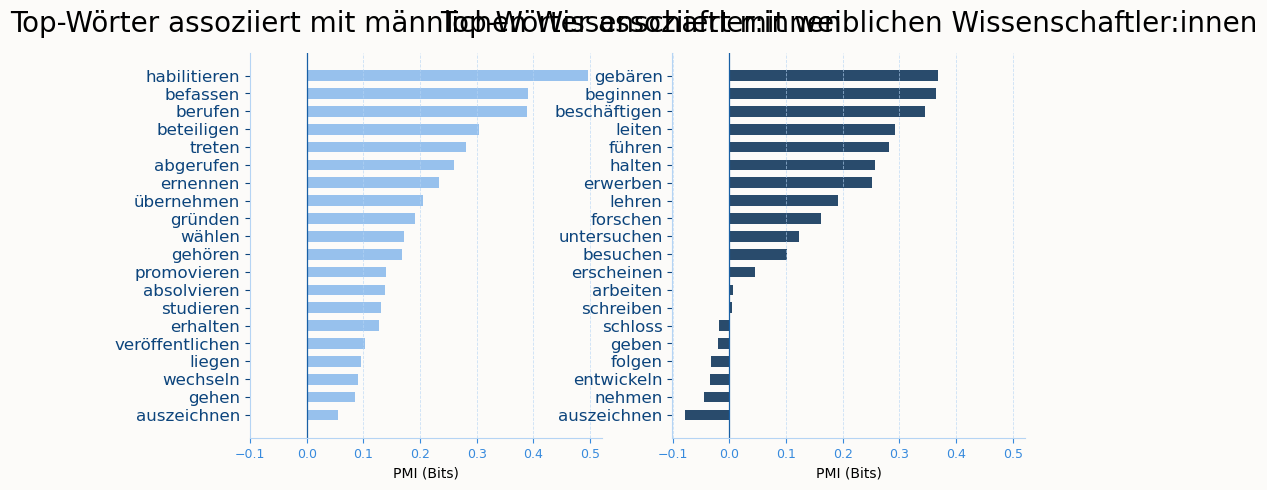

In [9]:
plot_pmi(pmi_data=pmi_dict, top_n=20)

### Scatterplot
Der Scatter-Plot zeigt die log-Häufigkeit eines Wortes bei männlichen vs. weiblichen Wissenschaftlern.
    - Die Diagonale (y = x)
        - Wörter  auf  der Linie kommen bei beiden Geschlechtern gleich häufig vor
        - Das sind meist neutrale Inhaltswörter (z.B. "Forschung", "Universität")
    - Abweichungen von der Diagonale
        - Wörter oberhalb häufiger bei  weiblichen  Wissenschaftlerinnen
        - Wörter unterhalb häufiger bei  männlichen  Wissenschaftlern
        - Je weiter weg von der Linie, desto stärker der Unterschied
        -

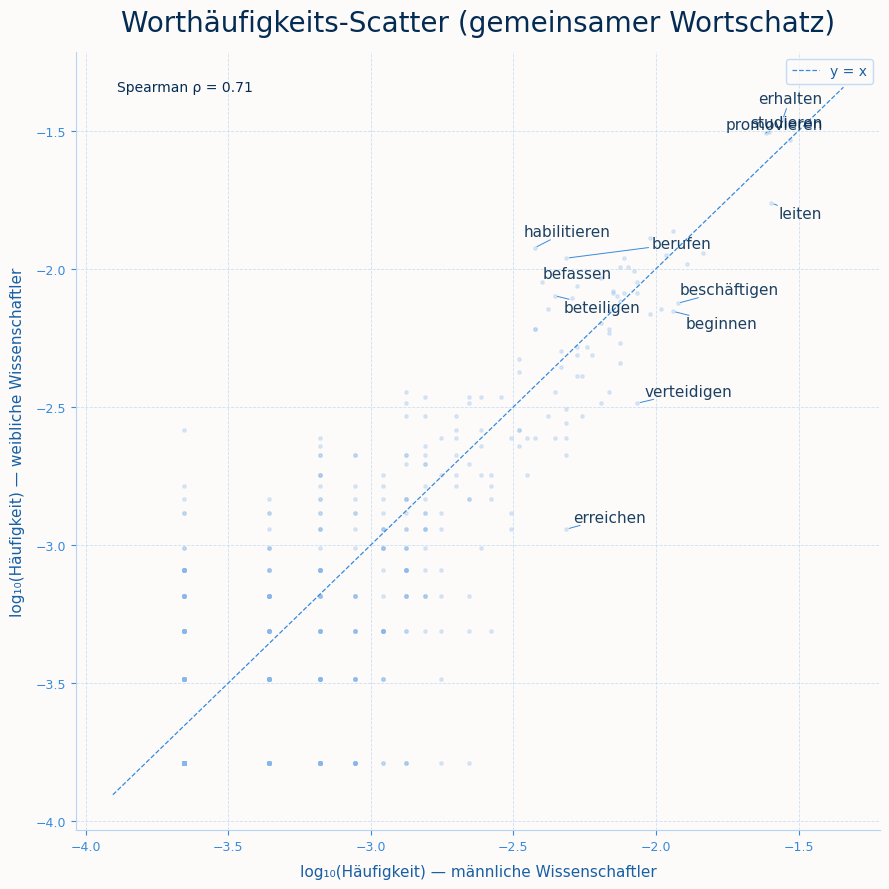

In [9]:
plot_rank_scatter(freq_m=freq[0], freq_f=freq[1])

## 3.3 Lexikon-basierte Analyse

Um zu prüfen, ob biografische Wikipedia-Artikel über Wissenschaftler:innen geschlechtsspezifisch unterschiedliche thematische Schwerpunkte setzen, wurde eine Lexikon-basierte Analyse durchgeführt. Im Unterschied zur PMI-Analyse, die datengetrieben Wortassoziationen identifiziert, folgt dieser Ansatz einer theoriegeleiteten Logik: Ausgangspunkt sind zwei semantische Kategorien: *Familie* und *Karriere*. Für beide Kategorien wurden Wortlisten auf Basis bestehender Forschung zu Gender-Bias in biografischen Texten sowie eigener inhaltlicher Überlegungen erstellt.

Für diese Analyse wurde, anders als bei der verbbasierten PMI-Analyse, der vollständige Wortschatz (Nomen, Verben, Adjektive, Adverbien) verwendet, da die Lexikoneinträge mehrheitlich aus Substantiven bestehen (z. B. *Habilitation*, *Auszeichnung*, *Mutterschaft*) und mit einem reinen Verbkorpus systematisch unterrepräsentiert worden wären. Die Texte wurden lemmatisiert, um beispielsweise die Grudnform von Verben zu erhalten, sowie um Stoppwörter bereinigt.

Für jede Kategorie wurde geprüft, ob die Wörter der Lexikoneinträge tatsächlich im Korpus der Wikipediartikel auftreten. Das Lexikon wurde iterativ erweitert und Wörter, die in den Artikeln nicht vorhanden sind entfernt. Die Häufigkeit der Lexikon-Treffer wurde pro Geschlecht auf 1.000 Wörter normalisiert, um Unterschiede in der Korpusgröße auszugleichen. Zur Prüfung, ob beobachtete Unterschiede statistisch signifikant sind, wurde ein Chi-Quadrat-Unabhängigkeitstest auf Basis der absoluten Trefferzahlen durchgeführt.

Limitierend ist anzumerken, dass die beiden Lexika unterschiedlich umfangreich sind (Karriere: 52 Wörter, Familie: 27 Wörter), was die Vergleichbarkeit der Trefferzahlen potenziell beeinflusst. Zudem handelt es sich bei den Lexika um eine selbst erstellte, nicht extern validierte Wortliste, deren Konstruktion einer gewissen Subjektivität unterliegt.


In [10]:
# Korpus erstellen mit aller Wörtern und nicht nur verben
corpus = preprocessing(data = df, STOPWORDS = STOPWORDS, nur_verben=False)

In [11]:
LEXIKA = {
    "Familie": {'eltern', 'geschwister', 'geboren', 'baby', 'neffe', 'partner', 'kind', 'heirat', 'sohn', 'schwanger', 'ehe', 'mutterschaft', 'familie', 'geburt', 'tochter', 'witwe', 'erziehung', 'mutter', 'verwitwet', 'vater', 'ehefrau', 'beziehung', 'haushalt', 'elternzeit', 'betreuung', 'verheiratet', 'ehemann'},
"Karriere":
    {'veröffentlichung', 'stelle', 'institutsleiter', 'nominiert', 'geschäftsführer', 'preis', 'monographie', 'promotion', 'labor', 'pionier', 'verteidigen', 'patent', 'bedeutend', 'befördern', 'award', 'wählen', 'stipendium', 'konferenz', 'abteilungsleiter', 'doktorarbeit', 'dekan', 'publikation', 'ernennen', 'amt', 'gewann', 'dissertation', 'gehalt', 'karriere', 'auszeichnung', 'arbeit', 'buch', 'übernehmen', 'studie', 'habilitation', 'forschung', 'direktor', 'wegweisend', 'einflussreich', 'abschluss', 'präsident', 'herausgeber', 'verliehen', 'erstmals', 'artikel', 'vorstand', 'graduiert', 'lehrstuhl', 'vortrag', 'position', 'beruf', 'erfindung', 'professur'}
}

In [12]:
GENUS_MAPPING = {
    "direktorin": "direktor",
    "herausgeberin": "herausgeber",
    "geschäftsführerin": "geschäftsführer",
    "partnerin": "partner",
    "institutsleiterin": "institutsleiter"
}

def normalisiere_genus(tokens, mapping):
    return [mapping.get(t, t) for t in tokens]

corpus_norm = {
    g: normalisiere_genus(tokens, GENUS_MAPPING)
    for g, tokens in corpus.items()
}

In [13]:
ergebnisse = lexikon_analyse(corpus_norm, LEXIKA) #Mit dem Genus-normalisierten Korpus


Familie:
  kind                 +0.851
  mutter               +0.438
  tochter              +0.385
  familie              +0.251
  ehemann              +0.214
  erziehung            +0.179
  ehe                  +0.152
  geboren              +0.143
  heirat               +0.063
  baby                 +0.036
  mutterschaft         +0.027
  verheiratet          +0.027
  schwanger            +0.027
  geschwister          +0.018
  geburt               +0.009
  verwitwet            +0.009
  eltern               +0.001
  vater                -0.016
  neffe                -0.018
  witwe                -0.018
  betreuung            -0.027
  haushalt             -0.036
  ehefrau              -0.053
  elternzeit           -0.089
  partner              -0.106
  beziehung            -0.150
  sohn                 -0.302
  → χ²=17.30, p=0.0000

Karriere:
  arbeit               +2.019
  forschung            +1.126
  verteidigen          +0.689
  preis                +0.637
  lehrstuhl            +0.

Die Ergebnisse zeigen ein klar unterschiedliches Bild für die beiden untersuchten Kategorien. Für die Kategorie **Familie** zeigt sich ein signifikanter Unterschied (χ²=17.30, p<.001). Inhaltlich konzentriert sich der Effekt auf wenige, aber starke Wörter: *Kind* (+0.851), *Mutter* (+0.438) und *Tochter* (+0.385) sind deutlich stärker mit weiblichen Biografien assoziiert, während *Sohn* (-0.302) und *Beziehung* (-0.150) stärker bei männlichen Biografien auftreten. Dieses Muster deckt sich mit den Befunden von Wagner et al. (2016) und Graells-Garrido et al. ([@graells-garrido_first_2015]), die für Wikipedia-Biografien ebenfalls zeigen konnten, dass Frauenartikel überproportional häufig familiäre und soziale Beziehungen thematisieren. Bemerkenswert ist, dass dieser Effekt primär durch die direkte Mutter-Kind-Beziehung getragen wird (*Kind*, *Mutter*, *Erziehung*, *Mutterschaft*), während andere Familienrollen wie *Vater*, *Ehefrau* oder *Witwe* nur schwach oder uneindeutig ausschlagen. Die Reduktion der Wissenschaftlerin auf die Mutterrolle ist ein in der Genderforschung wiederkehrendes Muster und steht im Einklang mit der Hypothese einer stärkeren biologisch-reproduktiven Rahmung von Frauenbiografien. Daher kann die Hypothese

Für die Kategorie **Karriere** ergibt sich dagegen kein statistisch signifikanter Unterschied (χ²=2.45, p=.117). Das bedeutet: Karrierebezogene Sprache ist in etwa gleich häufig in Biografien über Männer und Frauen vertreten. Bei genauerer Betrachtung der Einzelwörter fällt jedoch eine interessante Verschiebung auf: Wörter, die mit aktiver wissenschaftlicher Tätigkeit verbunden sind (*Forschung*, *Promotion*, *Dissertation*, *Lehrstuhl*, *Professur*) sind eher weiblich assoziiert, während Wörter, die formale institutionelle Macht und Status beschreiben (*Direktor*, *Präsident*, *Dekan*, *ernennen*, *wählen*, *Position*) eher männlich assoziiert sind.

Dieses Muster lässt sich so interpretieren: Der Gesamtumfang karrierebezogener Sprache unterscheidet sich nicht zwischen den Geschlechtern. Frauen werden also nicht grundsätzlich seltener im Kontext von Karriere beschrieben. Allerdings zeigt sich eine **qualitative Asymmetrie innerhalb der Kategorie**: Frauen werden eher über ihre fachliche Tätigkeit und Leistung beschrieben (Forschung, Lehre, akademischer Abschluss), Männer eher über formale Machtpositionen und institutionelle Anerkennung (Leitungsämter, Berufungen, Wahlen). Dieser Befund passt zum bereits diskutierten **Prove-it-again-Bias**: Frauen müssen ihre fachliche Kompetenz expliziter durch konkrete Leistungsnachweise (Publikationen, Dissertationen) belegen, während bei Männern eher der formale Statusaufstieg selbst thematisiert wird, unabhängig von der zugrunde liegenden fachlichen Leistung.

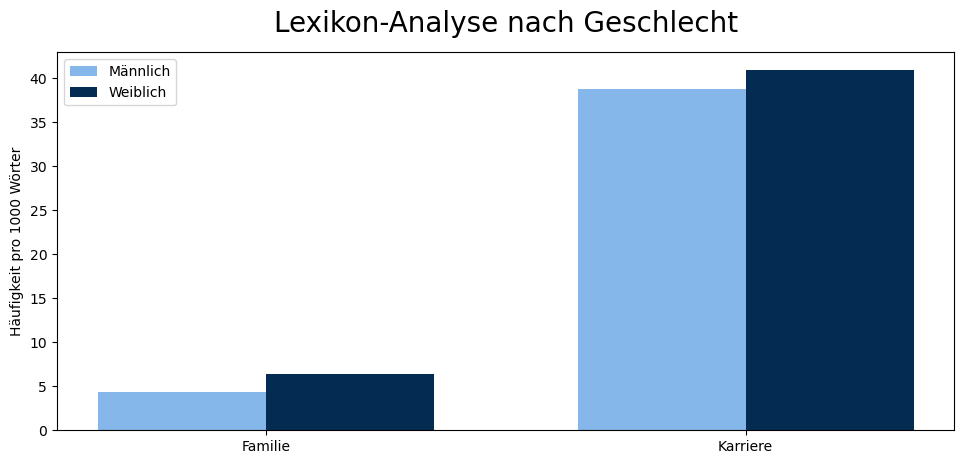

In [14]:
plot_lexikon(ergebnisse)

Entgegen der ursprünglichen Hypothese, dass männliche Wissenschaftler stärker mit Karriere- und Leistungssprache assoziiert sind, zeigt die Lexikon-Analyse ein gegenteiliges, wenn auch statistisch nicht signifikantes Muster (χ²=2.45, p=.117): Sowohl in der Kategorie *Karriere* als auch in der Kategorie *Leistung* sind weibliche Wissenschaftlerinnen tendenziell stärker repräsentiert.

Dieser Befund lässt sich nicht ohne Weiteres als Gegenbeleg zu Gender-Bias-Annahmen lesen, sondern könnte selbst Ausdruck eines bekannten Phänomens sein: dem sogenannten **Prove-it-again-Bias** (Williams & Multhaup, 2018). Demnach müssen Frauen ihre fachliche Kompetenz und ihre Leistungen häufiger und expliziter unter Beweis stellen bzw. benannt bekommen, um überhaupt als „bemerkenswert" wahrgenommen zu werden – während männliche Erfolge als selbstverständlicher gelten und seltener explizit hervorgehoben werden müssen. Ein Wikipedia-Artikel über eine Wissenschaftlerin könnte also gerade deshalb mehr Leistungsvokabular enthalten, weil ihre fachliche Reputation stärker explizit legitimiert werden muss.

Eine zweite, nicht ausschließende Erklärung betrifft den **Survivorship-Bias** der Stichprobe: Frauen, die einen Wikipedia-Artikel als Wissenschaftlerin erhalten, könnten im Schnitt eine selektivere, leistungsstärkere Teilgruppe darstellen als ihre männlichen Pendants – schlicht weil die Hürde zur Aufnahme in die Enzyklopädie für Frauen historisch höher lag.

# 4 Diskussion

Bereits die Problemdefinition ist nicht neutral. Die Entscheidung, Wikipedia als Datenquelle zu verwenden, setzt voraus, dass Wikipedia ein repräsentatives Abbild gesellschaftlicher Wahrnehmung von Geschlecht liefert – eine Annahme, die empirisch gut belegt ist, aber gleichzeitig bedeutet, dass die Analyse bestehende Plattform-Biases reproduziert und nicht gesellschaftliche Realität misst. Wikipedia ist kein Spiegel der Welt, sondern ein von einer spezifischen Autor:innengruppe konstruiertes Dokument: Studien zeigen konsistent, dass die überwiegende Mehrheit der Wikipedia-Autor:innen männlich, westlich und akademisch geprägt ist. Dieser Produktionsbias schlägt sich inhaltlich nieder – nicht nur darin, *welche* Personen einen Artikel erhalten, sondern auch darin, *wie* sie beschrieben werden. Die vorliegende Analyse misst daher primär den sprachlichen Bias einer homogenen Autor:innengruppe, nicht notwendigerweise einen gesamtgesellschaftlichen Diskurs.

Eng damit verbunden ist das Sampling-Problem. Die Entscheidung, nicht-binäre Personen aufgrund geringer Fallzahlen auszuschließen, ist methodisch nachvollziehbar, sollte aber nicht unreflektiert bleiben. Der Ausschluss reproduziert eine binäre Geschlechterlogik auf der Analyseebene, die auf der Gegenstandsebene bereits problematisch ist. Zudem ist die geringe Repräsentation nicht-binärer Personen auf Wikipedia selbst ein Befund, der des Kommentars bedarf: Unsichtbarkeit in den Daten ist keine neutrale Gegebenheit, sondern Ausdruck derselben strukturellen Asymmetrien, die die Analyse untersucht.

Auf der Ebene der Datenaufbereitung bringt die Entscheidung, ausschließlich Verben zu analysieren, einen systematischen Fokus mit sich, der bestimmte Formen von Bias sichtbar macht und andere verschleiert. Adjektivische Zuschreibungen – *ambitioniert*, *fürsorglich*, *emotional* – sind für die Geschlechterforschung mindestens ebenso relevant wie Verben, fehlen hier aber vollständig. Die Reduktion auf Verben ist linguistisch begründbar für das Deutsche, da Verben die Handlungsdimension von Subjekten kodieren; sie sollte im Paper jedoch explizit als theoretische Entscheidung gerahmt werden, nicht als technische Notwendigkeit.

Die PMI-Methode selbst ist anfällig für ein bekanntes Problem: Trotz des Frequenzthresholds (hier: Minimum 60 Vorkommen) bevorzugt PMI statistisch Wörter, die zwar häufig genug für den Filter sind, aber im Verhältnis zur Gesamtverteilung schief verteilt bleiben. PPMI oder PMI² wären robustere Alternativen und sollten zumindest diskutiert werden. Schwerwiegender ist jedoch die fehlende Prüfung auf Proxy-Variablen: Es ist nicht ausgeschlossen, dass gemessene Unterschiede nicht Geschlecht per se reflektieren, sondern konfundierte Variablen wie Profession, Epoche oder Nationalität. Eine Wissenschaftlerin des 19. Jahrhunderts und eine Politikerin des 21. Jahrhunderts sind beide als „weiblich" kodiert – ihre Beschreibungssprache dürfte jedoch aus sehr unterschiedlichen Gründen variieren.

Das Lexikon für die Kategorien *Familie* und *Karriere* ist theoriegeleitet konstruiert, was methodisch legitim ist – aber nur dann, wenn diese Konstruktion im Paper explizit begründet und idealerweise durch Literatur gestützt wird. Ein selbst erstelltes Lexikon ohne externe Validierung ist ein Single-Coder-Instrument mit unbekannter Reliabilität. Mindestens sollte eine Intercoder-Überprüfung oder ein Abgleich mit bestehenden validierten Lexika (z. B. aus der Sentiment- oder Genderforschung) erwogen werden. Neben den quantitativen Häufigkeitsunterschieden ist zu berücksichtigen, dass Gender-Bias sich nicht nur darin äußert, *ob* eine Kategorie wie Karriere oder Familie erwähnt wird, sondern auch *wie* sie sprachlich gerahmt ist. Dieselbe Tätigkeit kann je nach Geschlecht des Subjekts unterschiedlich konnotiert beschrieben werden – etwa als *ehrgeizig* versus *durchsetzungsstark*, oder als *fürsorglich* versus *aufopfernd*. Solche Unterschiede in der Wortwahl werden von einer reinen Häufigkeitsanalyse nicht erfasst, da Lexikon- und PMI-Ansätze lediglich messen, *welche* Wörter auftreten, nicht aber deren evaluative Färbung oder Konnotation. Eine vollständige Bias-Analyse müsste daher auch Sentiment- oder Konnotationsanalysen einschließen, um zu prüfen, ob semantisch ähnliche Sachverhalte je nach Geschlecht unterschiedlich bewertend dargestellt werden.

Schließlich fehlt eine intersektionale Perspektive vollständig. Die Analyse behandelt Geschlecht als isolierte Variable, obwohl Forschung seit Crenshaw (1989) zeigt, dass Geschlecht nicht unabhängig von Klasse, Ethnizität oder Profession wirkt. Dass *habilitieren* männlich assoziiert ist, könnte ebenso gut Klasseneffekte oder akademische Milieus abbilden wie Geschlechtereffekte. Ohne Kontrolle dieser Dimensionen bleibt die kausale Zurechnung auf Geschlecht spekulativ.


